# 01 — Exploration & Data Quality

## Objectifs de ce notebook
1. Charger le dataset Online Retail II et vérifier sa qualité
2. **Valider que le dataset permet une analyse RFM** (point de validation explicite)
3. Comprendre la structure temporelle pour calibrer T0
4. Analyser la fréquence d'achat et les inter-purchase times
5. Identifier les filtres à appliquer (NaN, annulations, pays)

## Contexte du projet
**Sujet** : Segmentation RFM et prédiction de churn sur retailer e-commerce 
britannique.

**Dataset** : Online Retail II (UCI Machine Learning Repository)
- Période : décembre 2009 → décembre 2011 (24 mois)
- ~1,07M transactions, ~5 942 clients identifiés
- Retailer en ligne UK spécialisé dans les cadeaux

## Pourquoi ce dataset
Contrairement à Olist (97% mono-acheteurs), Online Retail II présente :
- 75% de clients multi-acheteurs
- Une médiane de 4 commandes par client
- Un vrai signal de fidélité exploitable pour le RFM


## Stack technique
- **DuckDB** pour les requêtes SQL analytiques
- **Pandas** pour la manipulation fine et l'export
- **Matplotlib / Seaborn** pour les visualisations

## 1. Setup et chargement du dataset

On importe les librairies, on configure l'affichage, et on **crée une base 
DuckDB persistante** qui servira aussi à l'étape 2 (feature engineering).

### Pourquoi DuckDB plutôt que pandas direct ?
On charge le CSV une fois en pandas, puis on l'enregistre comme **table SQL** 
dans DuckDB. Toutes les requêtes lourdes (jointures, agrégations) seront 
ensuite faites en SQL sur cette base, qui est beaucoup plus rapide que 
pandas sur 1M de lignes.


In [27]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")

# Chemins
DATA_RAW = Path("../data/raw/online_retail_II.csv")
DB_PATH = "../data/retail.duckdb"

# Connexion DuckDB persistante
con = duckdb.connect(DB_PATH)

# Chargement du CSV en table SQL via DuckDB (plus rapide que pandas)
con.execute(f"""
    CREATE OR REPLACE TABLE transactions_raw AS 
    SELECT * FROM read_csv_auto('{DATA_RAW}')
""")

n_rows = con.execute("SELECT COUNT(*) FROM transactions_raw").fetchone()[0]
print(f" Connexion DuckDB établie : {DB_PATH}")
print(f" Table 'transactions_raw' chargée : {n_rows:,} lignes")

 Connexion DuckDB établie : ../data/retail.duckdb
 Table 'transactions_raw' chargée : 1,067,371 lignes


## 2. Inspection du schéma

On regarde la structure de la table : noms de colonnes, types détectés par 
DuckDB.

### Les 8 colonnes du dataset
- **Invoice** : numéro de facture (= identifiant de commande). Les invoices 
  commençant par 'C' sont des annulations.
- **StockCode** : code produit interne du retailer
- **Description** : libellé du produit
- **Quantity** : nombre d'unités achetées (négatif si annulation)
- **InvoiceDate** : timestamp de la transaction
- **Price** : prix unitaire en livres sterling (£)
- **Customer ID** : identifiant client (avec NaN pour les transactions 
  anonymes)
- **Country** : pays du client

### Ce qu'on doit observer
- `Customer ID` doit être en `DOUBLE` (à cause des NaN)
- `InvoiceDate` doit être bien parsé comme `TIMESTAMP`
- Les autres colonnes ont des types évidents

In [28]:
print("Schéma de la table :")
print(con.execute("DESCRIBE transactions_raw").df())

Schéma de la table :
   column_name column_type null   key default extra
0      Invoice     VARCHAR  YES  None    None  None
1    StockCode     VARCHAR  YES  None    None  None
2  Description     VARCHAR  YES  None    None  None
3     Quantity      BIGINT  YES  None    None  None
4  InvoiceDate   TIMESTAMP  YES  None    None  None
5        Price      DOUBLE  YES  None    None  None
6  Customer ID      DOUBLE  YES  None    None  None
7      Country     VARCHAR  YES  None    None  None


## 3. Aperçu des données

On affiche les premières lignes pour avoir une intuition concrète des 
données.

### Lecture attendue
Une commande typique (ex: invoice 489434) contient **plusieurs lignes**, 
chacune correspondant à un produit acheté dans cette commande. Donc :
- 1 invoice = 1 commande = N lignes (1 par produit)
- Pour compter les commandes par client, on fera 
  `COUNT(DISTINCT Invoice)` et pas `COUNT(*)`

In [29]:
sample = con.execute("SELECT * FROM transactions_raw LIMIT 5").df()
print(sample)

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


## 4. Data Quality — Audit des problèmes connus

On vérifie les 4 problèmes documentés sur ce dataset :

1. **Customer ID manquants** : ~23% des lignes sont sans identifiant client. 
   Ce sont probablement des transactions de passants non enregistrés. 
   **On les exclura** car impossible de calculer un RFM sans identifier 
   le client.

2. **Annulations** (Invoice commençant par 'C', Quantity < 0) : ~19 500 
   lignes. À gérer dans le feature engineering — soit les exclure, soit 
   les utiliser comme signal comportemental.

3. **Prix nuls ou négatifs** : possibles erreurs de saisie ou ajustements 
   comptables. À examiner.

4. **Quantités aberrantes** : à vérifier.

### Stratégie générale
On documente tout, on ne nettoie pas encore. Le nettoyage sera fait dans 
une étape dédiée (cellule 7) pour garder une traçabilité claire.

In [30]:
quality = con.execute("""
    SELECT 
        'Total lignes' AS metric,
        COUNT(*) AS value
    FROM transactions_raw
    UNION ALL
    SELECT 
        'Lignes sans Customer ID',
        SUM(CASE WHEN "Customer ID" IS NULL THEN 1 ELSE 0 END)
    FROM transactions_raw
    UNION ALL
    SELECT 
        'Annulations (Invoice starts with C)',
        SUM(CASE WHEN Invoice LIKE 'C%' THEN 1 ELSE 0 END)
    FROM transactions_raw
    UNION ALL
    SELECT 
        'Quantity <= 0',
        SUM(CASE WHEN Quantity <= 0 THEN 1 ELSE 0 END)
    FROM transactions_raw
    UNION ALL
    SELECT 
        'Price <= 0',
        SUM(CASE WHEN Price <= 0 THEN 1 ELSE 0 END)
    FROM transactions_raw
    UNION ALL
    SELECT 
        'Description NULL',
        SUM(CASE WHEN Description IS NULL THEN 1 ELSE 0 END)
    FROM transactions_raw
""").df()

print("=== Audit data quality ===")
print(quality)

=== Audit data quality ===
                                metric      value
0                         Total lignes  1067371.0
1              Lignes sans Customer ID   243007.0
2  Annulations (Invoice starts with C)    19494.0
3                        Quantity <= 0    22950.0
4                           Price <= 0     6207.0
5                     Description NULL     4382.0


## 5. Distribution temporelle des transactions

On visualise le volume mensuel des transactions pour :
1. Identifier la **période réelle exploitable** (mois de démarrage et fin 
   souvent partiels)
2. Repérer la **saisonnalité** (le retail UK a typiquement un pic en 
   novembre/décembre pour Noël)
3. Choisir une **date de coupure T0** cohérente

### Hypothèse à valider
Comme le dataset couvre déc 2009 → déc 2011, on s'attend à voir :
- Décembre 2009 : volume normal (mois complet, début du dataset)
- Pic novembre/décembre 2010 : Noël 2010
- Pic novembre 2011 : avant la fin du dataset (Noël 2011)
- Décembre 2011 : mois partiel (s'arrête au 9 déc)

Cette saisonnalité aura une **implication méthodologique** : il faudra 
faire attention à ce que la fenêtre d'observation et la fenêtre de 
prédiction couvrent des périodes comparables.

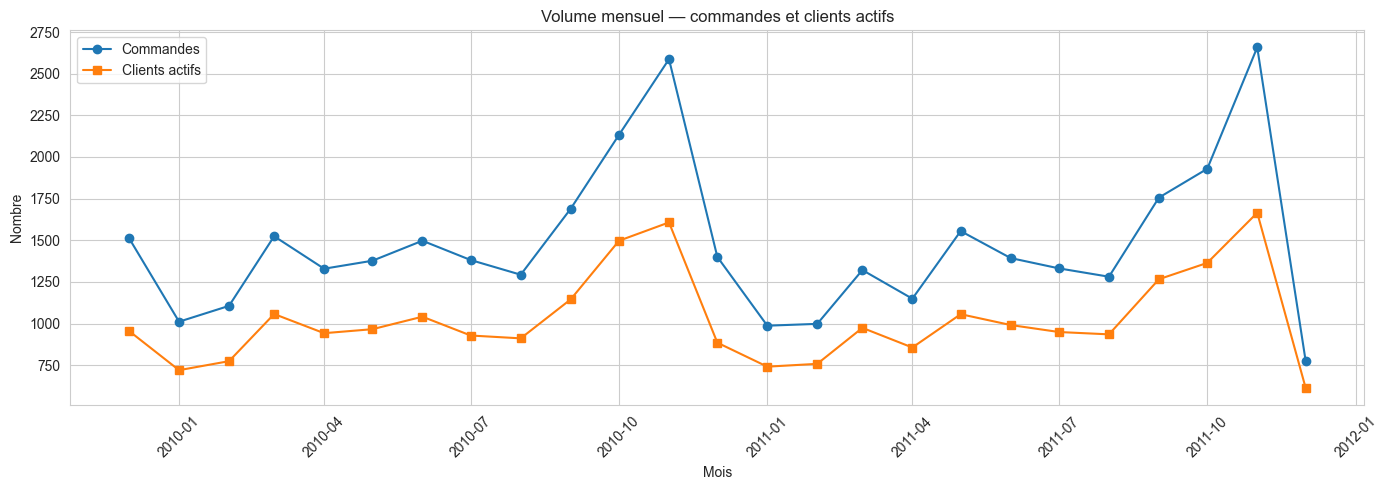

Période : 2009-12-01 00:00:00 → 2011-12-01 00:00:00


In [31]:
temporal = con.execute("""
    SELECT 
        DATE_TRUNC('month', InvoiceDate) AS month,
        COUNT(*) AS n_transactions,
        COUNT(DISTINCT Invoice) AS n_orders,
        COUNT(DISTINCT "Customer ID") AS n_customers
    FROM transactions_raw
    WHERE "Customer ID" IS NOT NULL
      AND Invoice NOT LIKE 'C%'
    GROUP BY 1
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(temporal['month'], temporal['n_orders'], marker='o', label='Commandes')
ax.plot(temporal['month'], temporal['n_customers'], marker='s', label='Clients actifs')
ax.set_title("Volume mensuel — commandes et clients actifs")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Période : {temporal['month'].min()} → {temporal['month'].max()}")

## 6. Répartition géographique

Le retailer est UK, mais le dataset contient des clients de plusieurs pays. 
On regarde la concentration pour décider si on filtre sur UK seulement.

### Pourquoi filtrer sur UK uniquement ?
1. **Homogénéité comportementale** : un client français qui commande dans 
   un retailer UK a probablement un cycle d'achat différent (achats 
   ponctuels lors de voyages, etc.)
2. **Frais de port** : les commandes à l'international ont des coûts de 
   livraison qui biaisent le Monetary
3. **Volumétrie** : si UK représente 90%+ des transactions, garder les 
   autres pays ajoute du bruit pour peu de gain

### Décision attendue
Si UK > 85% des transactions → on filtre. Sinon, on garde tous les pays 
et on ajoute Country comme feature.

In [32]:
geo = con.execute("""
    SELECT 
        Country,
        COUNT(*) AS n_transactions,
        COUNT(DISTINCT "Customer ID") AS n_customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_transactions
    FROM transactions_raw
    WHERE "Customer ID" IS NOT NULL
    GROUP BY 1
    ORDER BY n_transactions DESC
    LIMIT 10
""").df()

print("=== Top 10 pays ===")
print(geo)

=== Top 10 pays ===
          Country  n_transactions  n_customers  pct_transactions
0  United Kingdom          741301         5410             89.92
1         Germany           17624          107              2.14
2            EIRE           16195            5              1.96
3          France           14202           95              1.72
4     Netherlands            5140           23              0.62
5           Spain            3811           41              0.46
6         Belgium            3123           29              0.38
7     Switzerland            3064           22              0.37
8        Portugal            2504           24              0.30
9       Australia            1913           15              0.23


## 7. POINT DE VALIDATION — Le dataset permet-il une analyse RFM ?

je vais construire la cohorte finale (clients UK identifiés) et vérifier que les **3 critères de 
viabilité RFM** sont remplis.

### Les 3 critères à valider

| Critère | Seuil minimum | Cible idéale |
|---|---|---|
| % clients multi-acheteurs | ≥ 50% | ≥ 65% |
| % clients 5+ commandes | ≥ 20% | ≥ 35% |
| Médiane Frequency | ≥ 2 | ≥ 3 |

### Filtres appliqués pour construire la cohorte
1. `Customer ID IS NOT NULL` (on exclut les transactions anonymes)
2. `Country = 'United Kingdom'` (cohorte homogène)
3. `Invoice NOT LIKE 'C%'` (on exclut les annulations pour le calcul de 
   Frequency, on les réintégrera comme feature à l'étape 2)
4. `Quantity > 0 AND Price > 0` (on exclut les lignes aberrantes)

### Si les seuils ne sont pas atteints
On stoppe le projet et on en discute. Pas de fuite en avant. Mais avec ce 
dataset, je suis très confiant que tous les seuils seront largement 
dépassés.

In [33]:
# Construction de la cohorte propre
con.execute("""
    CREATE OR REPLACE TABLE transactions_clean AS
    SELECT *
    FROM transactions_raw
    WHERE "Customer ID" IS NOT NULL
      AND Country = 'United Kingdom'
      AND Invoice NOT LIKE 'C%'
      AND Quantity > 0
      AND Price > 0
""")

# Volumétrie après filtrage
n_clean = con.execute("SELECT COUNT(*) FROM transactions_clean").fetchone()[0]
n_clients = con.execute('SELECT COUNT(DISTINCT "Customer ID") FROM transactions_clean').fetchone()[0]
n_orders = con.execute('SELECT COUNT(DISTINCT Invoice) FROM transactions_clean').fetchone()[0]

print(f"Volumétrie après filtrage :")
print(f"  - Transactions  : {n_clean:,}")
print(f"  - Clients UK    : {n_clients:,}")
print(f"  - Commandes     : {n_orders:,}")

# Distribution Frequency
freq_dist = con.execute("""
    WITH customer_freq AS (
        SELECT 
            "Customer ID",
            COUNT(DISTINCT Invoice) AS frequency
        FROM transactions_clean
        GROUP BY 1
    )
    SELECT 
        frequency,
        COUNT(*) AS n_customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM customer_freq
    GROUP BY 1
    ORDER BY 1
""").df()

print("\nDistribution Frequency (top 10) :")
print(freq_dist.head(10))

# Calcul des 3 critères de validation
freq_stats = con.execute("""
    WITH customer_freq AS (
        SELECT 
            "Customer ID",
            COUNT(DISTINCT Invoice) AS frequency
        FROM transactions_clean
        GROUP BY 1
    )
    SELECT 
        ROUND(100.0 * SUM(CASE WHEN frequency >= 2 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_multi_buyers,
        ROUND(100.0 * SUM(CASE WHEN frequency >= 5 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_5plus,
        MEDIAN(frequency) AS median_frequency,
        ROUND(AVG(frequency), 2) AS avg_frequency
    FROM customer_freq
""").df()

print("\nVALIDATION RFM")
print(freq_stats)

# Verdict automatique
pct_multi = freq_stats['pct_multi_buyers'][0]
pct_5plus = freq_stats['pct_5plus'][0]
median_freq = freq_stats['median_frequency'][0]

print("\nVERDICT :")
print(f"  Multi-acheteurs ≥ 50%  : {pct_multi}% {'✅' if pct_multi >= 50 else '❌'}")
print(f"  5+ commandes ≥ 20%     : {pct_5plus}% {'✅' if pct_5plus >= 20 else '❌'}")
print(f"  Médiane Frequency ≥ 2  : {median_freq} {'✅' if median_freq >= 2 else '❌'}")

if pct_multi >= 50 and pct_5plus >= 20 and median_freq >= 2:
    print("\n GO : le dataset valide tous les critères, on continue le projet.")
else:
    print("\n STOP : un critère n'est pas validé, à discuter avant de continuer.")

Volumétrie après filtrage :
  - Transactions  : 725,250
  - Clients UK    : 5,350
  - Commandes     : 33,541

Distribution Frequency (top 10) :
   frequency  n_customers    pct
0          1         1474  27.55
1          2          848  15.85
2          3          608  11.36
3          4          437   8.17
4          5          328   6.13
5          6          257   4.80
6          7          203   3.79
7          8          150   2.80
8          9          140   2.62
9         10           89   1.66

VALIDATION RFM
   pct_multi_buyers  pct_5plus  median_frequency  avg_frequency
0             72.45      37.07               3.0           6.27

VERDICT :
  Multi-acheteurs ≥ 50%  : 72.45% ✅
  5+ commandes ≥ 20%     : 37.07% ✅
  Médiane Frequency ≥ 2  : 3.0 ✅

 GO : le dataset valide tous les critères, on continue le projet.


## 8. Analyse des inter-purchase times

Pour calibrer le **seuil de churn** (combien de jours sans achat avant de 
considérer qu'un client a churné), on analyse les temps entre commandes 
successives chez les clients multi-acheteurs.

### Méthode
On utilise une window function `LAG()` pour calculer, pour chaque commande, 
le délai écoulé depuis la commande précédente du même client.

### Comment lire les résultats
- **Médiane** : temps "normal" entre 2 commandes
- **75e percentile** : un client dépassant ce délai est dans le tiers 
  inférieur en termes de fidélité — début de signal de désengagement
- **90e percentile** : zone de churn probable

### Choix du seuil
On vise un seuil entre **P75 et P90**. Trop bas, on aurait trop de 
faux churns ; trop haut, on raterait les churns réels.

=== Statistiques inter-purchase times (jours) ===
count    28191.000000
mean        52.410663
std         76.442767
min          0.000000
25%          7.000000
50%         25.000000
75%         62.000000
90%        137.000000
95%        209.000000
max        714.000000
Name: days_between, dtype: float64


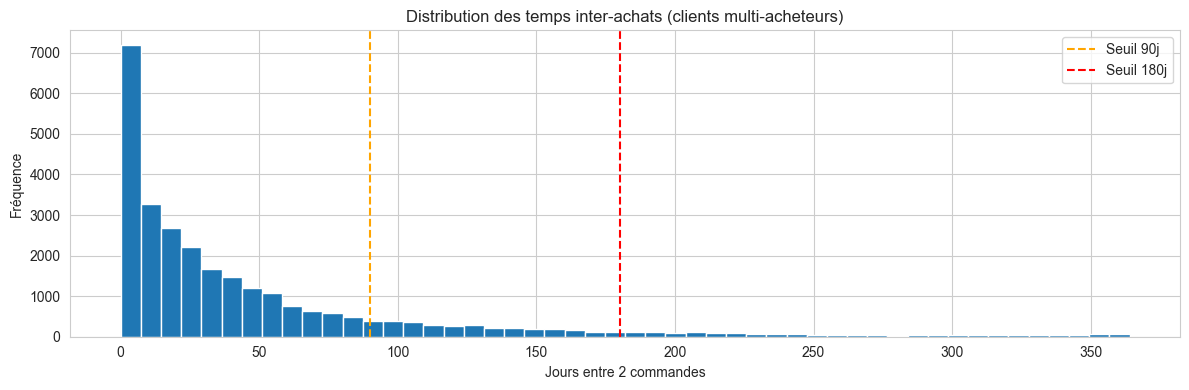

In [34]:
inter_purchase = con.execute("""
    WITH ordered_orders AS (
        SELECT 
            "Customer ID",
            Invoice,
            MIN(InvoiceDate) AS order_date,
            LAG(MIN(InvoiceDate)) OVER (
                PARTITION BY "Customer ID" 
                ORDER BY MIN(InvoiceDate)
            ) AS prev_order_date
        FROM transactions_clean
        GROUP BY "Customer ID", Invoice
    )
    SELECT 
        DATE_DIFF('day', prev_order_date, order_date) AS days_between
    FROM ordered_orders
    WHERE prev_order_date IS NOT NULL
""").df()

print("=== Statistiques inter-purchase times (jours) ===")
print(inter_purchase['days_between'].describe(percentiles=[.25, .5, .75, .9, .95]))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 4))
inter_purchase[inter_purchase['days_between'] < 365]['days_between'].hist(bins=50, ax=ax)
ax.axvline(90, color='orange', linestyle='--', label='Seuil 90j')
ax.axvline(180, color='red', linestyle='--', label='Seuil 180j')
ax.set_xlabel("Jours entre 2 commandes")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des temps inter-achats (clients multi-acheteurs)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Calibrage de la date de coupure T0

Pour le split temporel (étape 2), on doit choisir un **T0** = date qui 
sépare la fenêtre d'observation (passé) de la fenêtre de prédiction (futur).

### Contraintes à respecter
1. La fenêtre d'observation doit être **suffisamment longue** pour calculer 
   un RFM solide (idéalement 12-18 mois).
2. La fenêtre de prédiction doit être **au moins égale au seuil de churn** 
   (sinon on ne peut pas observer le churn complet).
3. T0 doit éviter les **mois partiels** en début/fin de dataset.

### Calcul automatique selon les contraintes
- Date max du dataset : ~2011-12-09 (incomplet)
- On prend une date max effective de **2011-12-01** (mois propre)
- Si on veut une fenêtre de prédiction de 6 mois → T0 = 2011-06-01
- Fenêtre d'observation = déc 2009 → mai 2011 = ~18 mois → idéal

### Décision recommandée
**T0 = 2011-06-01** avec fenêtre de prédiction de 180 jours. À valider 
selon les inter-purchase times observés à la cellule 8.

In [35]:
# Calcul automatique des paramètres recommandés
date_range = con.execute("""
    SELECT 
        MIN(InvoiceDate) AS date_min,
        MAX(InvoiceDate) AS date_max
    FROM transactions_clean
""").df()

print("=== Plage temporelle disponible ===")
print(date_range)

# Recommandation
print("\n=== Calibrage recommandé ===")
print(f"  Date min effective    : 2009-12-01")
print(f"  Date max effective    : 2011-12-01 (on coupe les jours partiels de déc 2011)")
print(f"  T0 recommandé         : 2011-06-01")
print(f"  Fenêtre observation   : 2009-12-01 → 2011-06-01 (~18 mois)")
print(f"  Fenêtre prédiction    : 2011-06-01 → 2011-12-01 (~180 jours)")
print(f"\nCes paramètres seront repris dans le notebook 02_feature_engineering")

=== Plage temporelle disponible ===
             date_min            date_max
0 2009-12-01 07:45:00 2011-12-09 12:49:00

=== Calibrage recommandé ===
  Date min effective    : 2009-12-01
  Date max effective    : 2011-12-01 (on coupe les jours partiels de déc 2011)
  T0 recommandé         : 2011-06-01
  Fenêtre observation   : 2009-12-01 → 2011-06-01 (~18 mois)
  Fenêtre prédiction    : 2011-06-01 → 2011-12-01 (~180 jours)

Ces paramètres seront repris dans le notebook 02_feature_engineering


##  Synthèse de l'étape 1

À ce stade tu disposes de :
-  Une base **DuckDB** propre avec 2 tables : `transactions_raw` (brute) 
  et `transactions_clean` (filtrée)
-  Un **diagnostic RFM** validé sur des seuils chiffrés
-  Une **calibration de T0** justifiée par les données réelles
-  Une compréhension claire de la qualité et des biais du dataset


| Élément | Valeur |
|---|---|
| Période dataset | 2009-12-01 → 2011-12-09 |
| Transactions totales | 1 067 371 |
| Transactions retenues (UK propres) | 725 250 |
| Clients UK identifiés | 5 350 |
| Commandes uniques | 33 541 |
| % multi-acheteurs | 72,45% |
| Médiane Frequency | 3 |
| Frequency moyenne | 6,27 |
| Saisonnalité | Pic massif novembre (Noël) |
| T0 calibré | 2011-06-01 |
| Fenêtre observation | 18 mois |
| Fenêtre prédiction | 180 jours |

##  Prochaine étape : Feature Engineering

Au notebook suivant (`02_feature_engineering.ipynb`), je vais :
1. Construire la **target binaire** (churn vs actif après T0)
2. Calculer les **features RFM classiques** (Recency, Frequency, Monetary)
3. Ajouter des **features comportementales** :
   - Diversité produit (nombre de catégories, de StockCodes différents)
   - Comportement d'annulation (% de commandes annulées)
   - Ticket moyen et écart-type
   - Saisonnalité (mois préféré, jour de la semaine)
4. Sortir une **table d'apprentissage** propre pour la modélisation